In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import holidays
import streamlit as st

In [2]:


# rutas relativas desde notebooks/
path_ventas = "../data/raw/entrenamiento/ventas.csv"
path_competencia = "../data/raw/entrenamiento/competencia.csv"

df_ventas = pd.read_csv(path_ventas, encoding="utf-8", sep=",")
df_competencia = pd.read_csv(path_competencia, encoding="utf-8", sep=",")

# Conversión de fecha a datetime
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'], errors='coerce')
df_competencia['fecha'] = pd.to_datetime(df_competencia['fecha'], errors='coerce')

print("Ventas:", df_ventas.shape)
print("Competencia:", df_competencia.shape)
display(df_ventas.head())
display(df_competencia.head())

Ventas: (3552, 10)
Competencia: (3552, 5)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [3]:
# 1. Info básica y tipos
print("=== Info ===")
df_ventas.info()

print("\n=== Tipos de datos ===")
print(df_ventas.dtypes)

# 2. Nulos y porcentaje
print("\n=== Nulos por columna ===")
nulls = df_ventas.isnull().sum()
pct_nulls = (nulls / len(df_ventas) * 100).round(2)
nulls_df = pd.DataFrame({"nulos": nulls, "% nulos": pct_nulls})
print(nulls_df)

# 3. Duplicados
total_duplicados = df_ventas.duplicated().sum()
print(f"\n=== Duplicados ===\nTotal filas: {len(df_ventas)}\nDuplicados exactos: {total_duplicados}")

# 4. Estadística descriptiva numérica
print("\n=== Estadística descriptiva (numérica) ===")
print(df_ventas.describe(include=["number"]).transpose())

# 5. Estadística descriptiva categórica
print("\n=== Estadística descriptiva (objetos/categorías) ===")
print(df_ventas.describe(include=["object", "category"]).transpose())

# 6. Rango de fechas si hay campo fecha
if "fecha" in df_ventas.columns:
    df_ventas["fecha"] = pd.to_datetime(df_ventas["fecha"], errors="coerce")
    print("\n=== Fecha min/max y nulos en fecha ===")
    print("min:", df_ventas["fecha"].min())
    print("max:", df_ventas["fecha"].max())
    print("nulos en fecha:", df_ventas["fecha"].isna().sum())

# 7. Valores únicos por columna
print("\n=== Valores únicos por columna (top 20) ===")
for col in df_ventas.columns:
    if df_ventas[col].nunique() <= 20:
        print(f"{col}: {df_ventas[col].nunique()} únicos -> {df_ventas[col].unique()}")
    else:
        print(f"{col}: {df_ventas[col].nunique()} únicos (se omite lista larga)")

# 8. Primeras filas + colas
print("\n=== Primeras filas ===")
display(df_ventas.head())
print("\n=== Últimas filas ===")
display(df_ventas.tail())

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB

=== Tipos de datos ===
fecha                datetime64[ns]
producto_id                  object
nombre                       obj

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74



=== Últimas filas ===


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
3547,2024-11-30,PROD_020,Quechua MH500,Outdoor,Ropa Montaña,80,False,9,73.6,662.4
3548,2024-11-30,PROD_021,Manduka PRO Yoga Mat,Wellness,Esterilla Yoga,130,True,25,124.8,3120.0
3549,2024-11-30,PROD_022,Gaiam Premium Yoga Block,Wellness,Bloque Yoga,20,False,9,19.2,172.8
3550,2024-11-30,PROD_023,Liforme Yoga Pad,Wellness,Rodillera Yoga,35,False,9,33.6,302.4
3551,2024-11-30,PROD_024,Lotuscrafts Yoga Bolster,Wellness,Cojín Yoga,50,False,9,48.0,432.0


In [4]:
# Análisis de calidad de datos para df_competencia
import pandas as pd
import numpy as np

# 1. Información general
df_info = df_competencia.info()

# 2. Valores nulos
df_nulos = df_competencia.isnull().sum()

# 3. Porcentaje de valores nulos
df_nulos_pct = (df_competencia.isnull().mean() * 100).round(2)

# 4. Duplicados
num_duplicados = df_competencia.duplicated().sum()

# 5. Estadísticos descriptivos
df_describe = df_competencia.describe(include='all')

# 6. Tipos de datos
df_tipos = df_competencia.dtypes

# 7. Valores únicos por columna
df_unicos = df_competencia.nunique()

# Mostrar resultados
print('--- INFORMACIÓN GENERAL ---')
df_competencia.info()
print('\n--- VALORES NULOS POR COLUMNA ---')
print(df_nulos)
print('\n--- PORCENTAJE DE NULOS POR COLUMNA ---')
print(df_nulos_pct)
print(f"\n--- FILAS DUPLICADAS: {num_duplicados} ---")
print('\n--- ESTADÍSTICOS DESCRIPTIVOS ---')
print(df_describe)
print('\n--- TIPOS DE DATOS ---')
print(df_tipos)
print('\n--- VALORES ÚNICOS POR COLUMNA ---')
print(df_unicos)

# Resumen final
def resumen_calidad():
    resumen = []
    if num_duplicados > 0:
        resumen.append(f"Hay {num_duplicados} filas duplicadas.")
    else:
        resumen.append("No hay filas duplicadas.")
    if df_nulos.sum() > 0:
        resumen.append("Existen valores nulos en las siguientes columnas:")
        resumen.append(str(df_nulos[df_nulos > 0]))
    else:
        resumen.append("No hay valores nulos.")
    resumen.append("Tipos de datos:\n" + str(df_tipos))
    resumen.append("Valores únicos por columna:\n" + str(df_unicos))
    return "\n".join(resumen)

print('\n--- RESUMEN FINAL ---')
print(resumen_calidad())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 138.9+ KB
--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   fl

In [5]:
# Integración de df_ventas y df_competencia en un solo dataframe
df = pd.merge(df_ventas, df_competencia, on=["fecha", "producto_id"], how="inner")
print(f"Shape del dataframe integrado: {df.shape}")
display(df.head())

Shape del dataframe integrado: (3552, 13)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


## Análisis exploratorio DDF

A continuación se presentan diferentes análisis exploratorios con gráficos utilizando seaborn, siguiendo las instrucciones solicitadas:

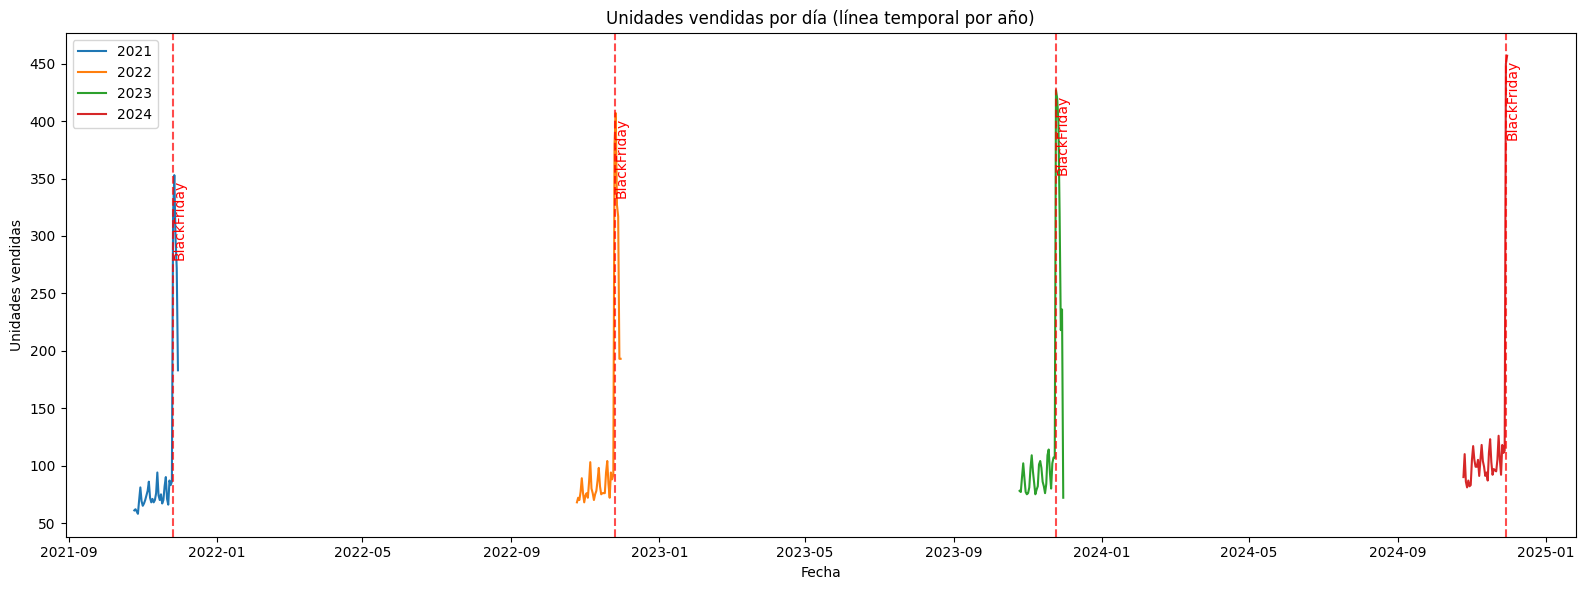

In [6]:
# Gráfico de líneas temporales por año con suma de unidades vendidas y marcado de BlackFridays
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.holiday import USFederalHolidayCalendar

# Aseguramos el formato de fecha
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
df_ventas['año'] = df_ventas['fecha'].dt.year

# Identificamos los BlackFridays (último viernes de noviembre de cada año)
def get_blackfridays(years):
    bfs = []
    for y in years:
        nov = pd.date_range(start=f'{y}-11-01', end=f'{y}-11-30', freq='D')
        fridays = nov[nov.weekday == 4]
        bfs.append(fridays[-1])
    return bfs

years = df_ventas['año'].unique()
blackfridays = get_blackfridays(years)

plt.figure(figsize=(16, 6))
for y in sorted(years):
    data = df_ventas[df_ventas['año'] == y].groupby('fecha')['unidades_vendidas'].sum()
    sns.lineplot(x=data.index, y=data.values, label=str(y))
    # Marcar BlackFriday
    bf = [d for d in blackfridays if d.year == y][0]
    plt.axvline(bf, color='red', linestyle='--', alpha=0.7)
    plt.text(bf, plt.ylim()[1]*0.95, 'BlackFriday', color='red', rotation=90, va='top')
plt.title('Unidades vendidas por día (línea temporal por año)')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\usuario\AppData\Local\Temp\ipykernel_19272\1705438773.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_ventas, x='dia_semana', y='unidades_vendidas', estimator=sum, order=orden_dias, ci=None)


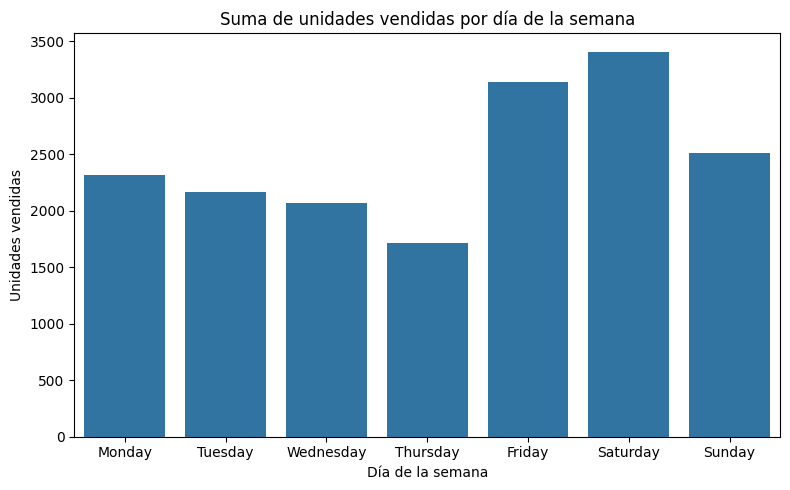

In [7]:
# Gráfico de suma de unidades vendidas por día de la semana
plt.figure(figsize=(8,5))
df_ventas['dia_semana'] = df_ventas['fecha'].dt.day_name()
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df_ventas, x='dia_semana', y='unidades_vendidas', estimator=sum, order=orden_dias, ci=None)
plt.title('Suma de unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.tight_layout()
plt.show()

C:\Users\usuario\AppData\Local\Temp\ipykernel_19272\2884420423.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_ventas, x='categoria', y='unidades_vendidas', estimator=sum, ci=None, order=df_ventas.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)


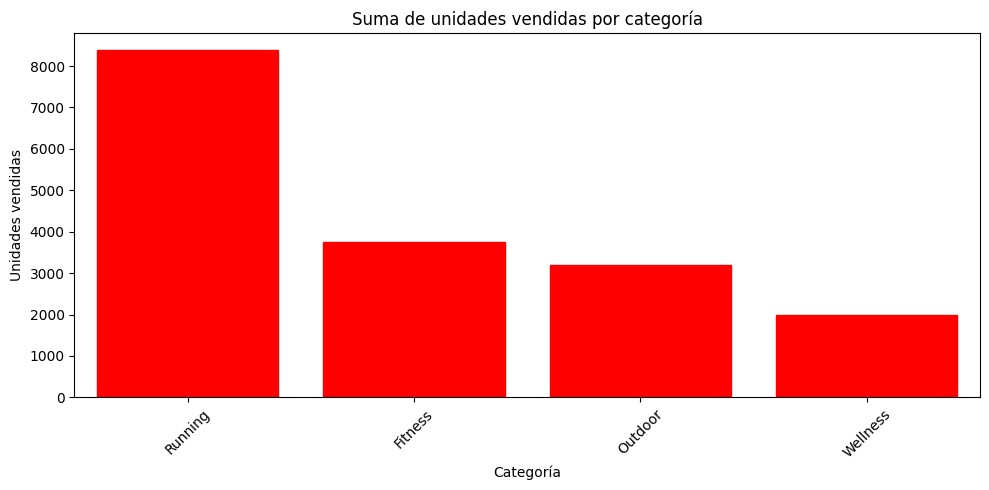

In [8]:
# Gráfico de suma de unidades vendidas por categoría
plt.figure(figsize=(10,5))
sns.barplot(data=df_ventas, x='categoria', y='unidades_vendidas', estimator=sum, ci=None, order=df_ventas.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)
plt.title('Suma de unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
for barra in plt.gca().patches:
    barra.set_color("red")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\usuario\AppData\Local\Temp\ipykernel_19272\3433717205.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_ventas, x='subcategoria', y='unidades_vendidas', estimator=sum, ci=None, order=df_ventas.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)


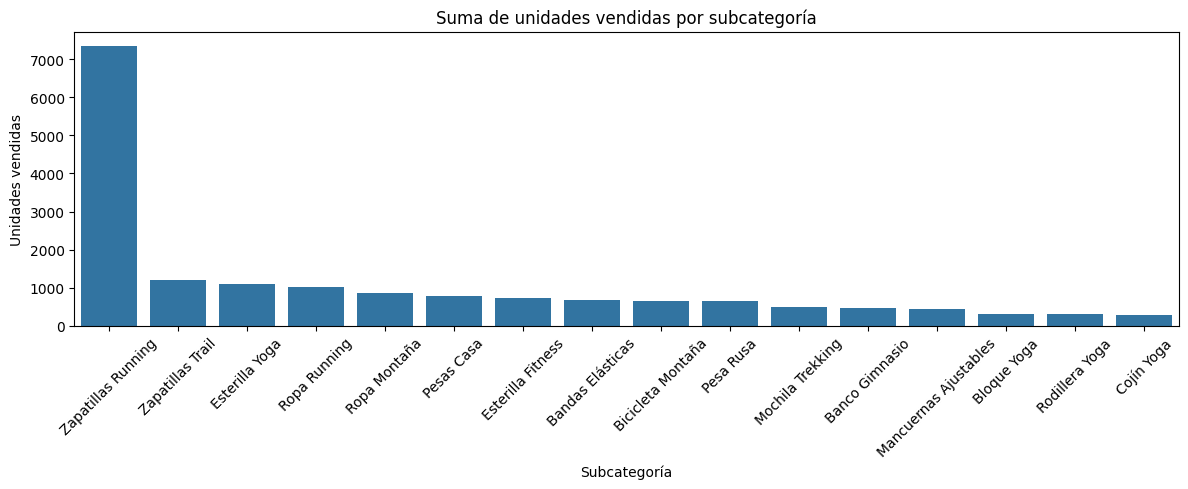

In [9]:
# Gráfico de suma de unidades vendidas por subcategoría
plt.figure(figsize=(12,5))
sns.barplot(data=df_ventas, x='subcategoria', y='unidades_vendidas', estimator=sum, ci=None, order=df_ventas.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).index)
plt.title('Suma de unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\usuario\AppData\Local\Temp\ipykernel_19272\2764258513.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_ventas[df_ventas['nombre'].isin(productos_top)], x='nombre', y='unidades_vendidas', estimator=sum, ci=None, order=productos_top)


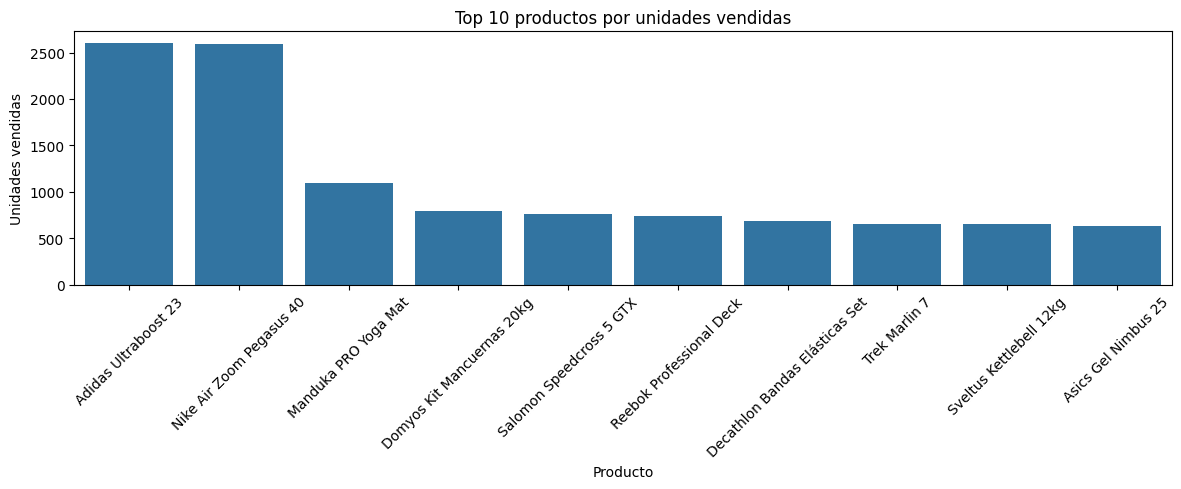

In [10]:
# Gráfico de los top productos por unidades vendidas
n_top = 10
productos_top = df_ventas.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(n_top).index
plt.figure(figsize=(12,5))
sns.barplot(data=df_ventas[df_ventas['nombre'].isin(productos_top)], x='nombre', y='unidades_vendidas', estimator=sum, ci=None, order=productos_top)
plt.title(f'Top {n_top} productos por unidades vendidas')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

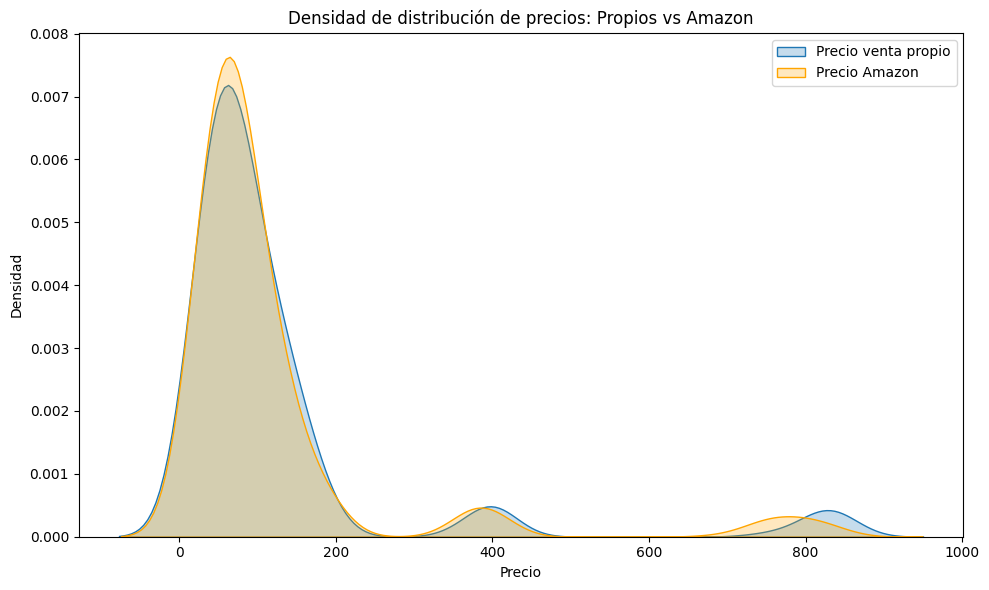

In [11]:
# Análisis de densidad de distribución de precios propios y de Amazon
plt.figure(figsize=(10,6))
sns.kdeplot(df_ventas['precio_venta'], label='Precio venta propio', fill=True)
sns.kdeplot(df_competencia['Amazon'], label='Precio Amazon', fill=True, color='orange')
plt.title('Densidad de distribución de precios: Propios vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# 🤖 Variable de descuento porcentual en el dataframe df
# (precio_venta - precio_base) / precio_base * 100
# Si el precio_base es 0, el resultado será NaN

df['descuento_porcentaje'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100

# Vista previa de la nueva variable
df[['fecha', 'producto_id', 'precio_base', 'precio_venta', 'descuento_porcentaje']].head(10)

,fecha,producto_id,precio_base,precio_venta,descuento_porcentaje
0,2021-10-25,PROD_001,115,118.36,2.921739
1,2021-10-25,PROD_002,135,136.82,1.348148
2,2021-10-25,PROD_003,85,84.93,-0.082353
3,2021-10-25,PROD_004,75,75.42,0.560000
4,2021-10-25,PROD_005,35,35.87,2.485714
5,2021-10-25,PROD_006,65,65.51,0.784615
6,2021-10-25,PROD_007,70,70.98,1.400000
7,2021-10-25,PROD_008,65,66.60,2.461538
8,2021-10-25,PROD_009,400,392.31,-1.922500
9,2021-10-25,PROD_010,175,174.92,-0.045714


In [13]:
# 🤖 Creación de variables lag y media móvil de 7 días para 'unidades_vendidas' en el dataframe df
# Se calcula por producto y año para evitar mezclar años

def crear_lags_y_media_df(df):
    df = df.sort_values(['producto_id', 'anio', 'fecha'])
    # Crear lags del 1 al 7
    for lag in range(1, 8):
        df[f'unidades_vendidas_lag{lag}'] = df.groupby(['producto_id', 'anio'])['unidades_vendidas'].shift(lag)
    # Media móvil de 7 días
    df['unidades_vendidas_mm7'] = df.groupby(['producto_id', 'anio'])['unidades_vendidas'].transform(lambda x: x.rolling(window=7, min_periods=1).mean().shift(1))
    return df

# Aplicar la función
df = crear_lags_y_media_df(df)

# Eliminar registros con nulos en los nuevos lags o media móvil
cols_lag_mm = [f'unidades_vendidas_lag{i}' for i in range(1,8)] + ['unidades_vendidas_mm7']
df = df.dropna(subset=cols_lag_mm).reset_index(drop=True)

# Vista previa
df[[
    'fecha', 'producto_id', 'unidades_vendidas',
    *cols_lag_mm
]].head(10)

KeyError: 'anio'

In [ ]:
df.groupby('anio').size()

anio
2021    720
2022    720
2023    720
2024    720
dtype: int64

In [ ]:
# 🤖 Variables temporales y de calendario usando holidays para España, pero sobre el dataframe integrado df
import pandas as pd
import numpy as np
import holidays

# Asegúrate de que la columna 'fecha' está en formato datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Instancia de festivos en España
es_holidays = holidays.country_holidays('ES', years=df['fecha'].dt.year.unique())

# Variables temporales
# Año
df['anio'] = df['fecha'].dt.year
# Mes
df['mes'] = df['fecha'].dt.month
# Día del mes
df['dia_mes'] = df['fecha'].dt.day
# Día de la semana (0=Lunes, 6=Domingo)
df['dia_semana'] = df['fecha'].dt.weekday
# Nombre del día de la semana
df['nombre_dia'] = df['fecha'].dt.day_name(locale='es_ES')
# Es fin de semana
df['es_fin_de_semana'] = df['dia_semana'].isin([5,6]).astype(int)
# Es festivo nacional
df['es_festivo'] = df['fecha'].isin(es_holidays).astype(int)
# Es Black Friday (último viernes de noviembre)
def es_black_friday(fecha):
    if fecha.month == 11:
        ultimo_viernes = max([d for d in pd.date_range(start=fecha.replace(day=1), end=fecha.replace(day=30)) if d.weekday() == 4])
        return int(fecha == ultimo_viernes)
    return 0
df['es_black_friday'] = df['fecha'].apply(es_black_friday)
# Es Cyber Monday (primer lunes después de Black Friday)
def es_cyber_monday(fecha):
    if fecha.month == 11 or fecha.month == 12:
        dias_nov = pd.date_range(start=fecha.replace(month=11, day=1), end=fecha.replace(month=11, day=30))
        black_friday = max([d for d in dias_nov if d.weekday() == 4])
        cyber_monday = black_friday + pd.Timedelta(days=3)
        return int(fecha == cyber_monday)
    return 0
df['es_cyber_monday'] = df['fecha'].apply(es_cyber_monday)
# Día del año
df['dia_anio'] = df['fecha'].dt.dayofyear
# Semana del año
df['semana_anio'] = df['fecha'].dt.isocalendar().week
# Primer día del mes
df['es_primer_dia_mes'] = (df['dia_mes'] == 1).astype(int)
# Último día del mes
df['es_ultimo_dia_mes'] = (df['fecha'] == df['fecha'] + pd.offsets.MonthEnd(0)).astype(int)
# Trimestre
df['trimestre'] = df['fecha'].dt.quarter
# Es festivo o fin de semana
df['es_festivo_o_finde'] = ((df['es_festivo'] == 1) | (df['es_fin_de_semana'] == 1)).astype(int)
# Es Navidad (24, 25, 26 de diciembre)
df['es_navidad'] = df['fecha'].dt.month.eq(12) & df['fecha'].dt.day.isin([24])
df['es_navidad'] = df['es_navidad'].astype(int)
# Es Fin de Año (31 de diciembre y 1 de enero)
df['es_fin_anio'] = ((df['fecha'].dt.month.eq(12) & df['fecha'].dt.day.eq(31)) |
                    (df['fecha'].dt.month.eq(1) & df['fecha'].dt.day.eq(1)))
df['es_fin_anio'] = df['es_fin_anio'].astype(int)

# Vista previa de las nuevas variables
df.head()

C:\Users\usuario\AppData\Local\Temp\ipykernel_16328\1922539226.py:26: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['es_festivo'] = df['fecha'].isin(es_holidays).astype(int)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_black_friday,es_cyber_monday,dia_anio,semana_anio,es_primer_dia_mes,es_ultimo_dia_mes,trimestre,es_festivo_o_finde,es_navidad,es_fin_anio
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,0,0,298,43,0,0,4,0,0,0
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,0,0,298,43,0,0,4,0,0,0
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,0,0,298,43,0,0,4,0,0,0
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,0,0,298,43,0,0,4,0,0,0
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,0,0,298,43,0,0,4,0,0,0


In [ ]:
# 🤖 Precio competencia y ratio de precio respecto a la competencia
# Calcula el precio promedio de Amazon, Decathlon y Deporvillage para cada producto y fecha
df['precio_competencia'] = df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)


# Creamos el ratio de precio respecto a la competencia
df['ratio_precio_competencia'] = df['precio_venta'] / df['precio_competencia']

# Eliminamos las columnas de Amazon, Decathlon y Deporvillage de df_competencia
df = df.drop(['Amazon', 'Decathlon', 'Deporvillage'], axis=1)

# Vista previa de las nuevas variables
df[['fecha', 'producto_id', 'precio_venta', 'precio_competencia', 'ratio_precio_competencia']].head(10)

,fecha,producto_id,precio_venta,precio_competencia,ratio_precio_competencia
0,2021-11-01,PROD_001,115.07,95.353333,1.206775
1,2021-11-02,PROD_001,116.10,96.153333,1.207446
2,2021-11-03,PROD_001,114.58,95.240000,1.203066
3,2021-11-04,PROD_001,112.23,96.590000,1.161922
4,2021-11-05,PROD_001,113.81,96.170000,1.183425
5,2021-11-06,PROD_001,117.80,95.436667,1.234326
6,2021-11-07,PROD_001,116.04,96.153333,1.206822
7,2021-11-08,PROD_001,113.46,97.003333,1.169651
8,2021-11-09,PROD_001,113.98,96.933333,1.175860
9,2021-11-10,PROD_001,117.57,96.343333,1.220323


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha                     2880 non-null   datetime64[ns]
 1   producto_id               2880 non-null   object        
 2   nombre                    2880 non-null   object        
 3   categoria                 2880 non-null   object        
 4   subcategoria              2880 non-null   object        
 5   precio_base               2880 non-null   int64         
 6   es_estrella               2880 non-null   bool          
 7   unidades_vendidas         2880 non-null   int64         
 8   precio_venta              2880 non-null   float64       
 9   ingresos                  2880 non-null   float64       
 10  anio                      2880 non-null   int32         
 11  mes                       2880 non-null   int32         
 12  dia_mes             

In [ ]:
# 🤖 Copia de variables y one hot encoding sobre df
# Creamos las columnas con sufijo _h
for col in ['nombre', 'categoria', 'subcategoria']:
    df[f'{col}_h'] = df[col]

# One hot encoding sobre las nuevas columnas

df = pd.get_dummies(df, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], drop_first=False)

# Vista previa de las nuevas columnas one hot
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,False,False,False,False,False,False,False,False,True,False
1,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,116.10,1161.00,...,False,False,False,False,False,False,False,False,True,False
2,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,114.58,1260.38,...,False,False,False,False,False,False,False,False,True,False
3,2021-11-04,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,112.23,1346.76,...,False,False,False,False,False,False,False,False,True,False
4,2021-11-05,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,113.81,1138.10,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# 🤖 Guardar el dataframe df en la carpeta data/processed con encoding compatible
ruta_guardado = '../data/processed/df.csv'
df.to_csv(ruta_guardado, index=False, encoding='utf-8-sig', errors='replace')
print(f"DataFrame guardado en {ruta_guardado}")

DataFrame guardado en ../data/processed/df.csv


In [ ]:
df.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos', 'Amazon', 'Decathlon', 'Deporvillage',
       'descuento_porcentaje'],
      dtype='object')